In [ ]:
import numpy as np
#import medal
import anndata as ann
import torch
import torch.nn as nn
import pandas
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm
from captum.attr import FeatureAblation
from captum.attr import IntegratedGradients

In [2]:
### load gene markers and datasets
cell_type_markers = pandas.read_excel('data/mmc3.xlsx', header=1, sheet_name=0) 
differential_markers=pandas.read_excel('data/mmc3.xlsx', header=1, sheet_name=1)

genes_data=pandas.read_csv("medal_meta/var_genes.csv")
genes=genes_data['index'].tolist()

comb_data=ann.read_h5ad("data/processed_data.h5ad")
cell_types=list(set(comb_data.obs['cell.types']))
cell_types_train=pandas.read_csv("medal_immune_meta/obs_train.csv")['cell.types'].tolist()   

x_train=np.load('medal_immune_meta/X_train.npy')    
samples_train=pandas.read_csv("medal_immune_meta/obs_train.csv")['samples'].tolist()       
obs_train=pandas.read_csv("medal_immune_meta/obs_train.csv")    

In [3]:
#convert markers list to string

diff=differential_markers.loc[:, differential_markers.columns!='MALIGNANT'].to_numpy().flatten()
diff=diff.astype(str)
diff=diff[~(diff=='nan')]
print(len(np.intersect1d(diff, np.array(genes).astype(str))))

subset=['ENDOTHELIAL CELL', 'CAF', 'B CELL', 'NAIVE CD4 T CELL', 'NK CELL', 'CYTOTOXIC CD8 T CELL', 'MACROPHAGE', 'CYTOTOXIC T CELL (SPECIFIC MARKERS)', 'EXHAUSTED T CELL (SPECIFIC MARKERS)', 'NAIVE T CELL (SPECIFIC MARKERS)']
cell=cell_type_markers.loc[:, cell_type_markers.columns.isin(subset)].to_numpy().flatten()
cell=cell.astype(str)
cell=cell[~(cell=='nan')]
print(len(np.intersect1d(cell, np.array(genes).astype(str))))

842
62


In [ ]:
#load the MEDAL object
from medal.io import load_model

from medal.io import load_model  
model=load_model(
    ckpt_path='medal_immune_meta/medal_tsne2_35_seed0_ckpts/final.pt',
    input_dim=6912,
    hidden_dims=(512,512,512),
    latent_dim=2,
    activation='SELU',
    use_batchnorm=False,
    dropout_rate=0.0
)

In [4]:
def compute_loss(x_train, model):
    # pass in immune dataset
    reconstructed, embedding=model(torch.tensor(x_train).float())
    recon_loss=np.mean((x_train-reconstructed.detach().numpy())**2, axis=1)
    
    print(recon_loss.shape)
    return recon_loss

In [29]:
def get_columns(top_features, top_labels, df):
    for ind,i in enumerate(top_labels):
        col=None
        if i==1:
            value=top_features[ind]
            col=df.columns[df.eq(value).any()][0]

        print(col,end=" ")   
    print()

In [5]:
x_train.shape #expected: (3292, 6912)

(3292, 6912)

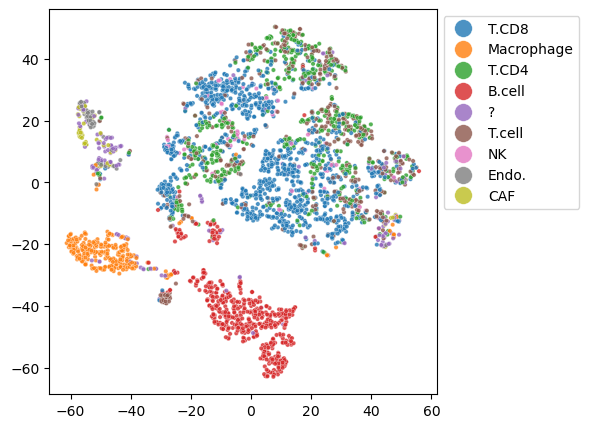

In [6]:
#get teacher model, following the paper's methods (PCA -> t-SNE)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)
tsne=TSNE(n_components=2, perplexity=35)
tsne_embed=tsne.fit_transform(x_pca)

fig, ax=plt.subplots(figsize=(5,5))
a=sns.scatterplot(x=tsne_embed[:,0], y=tsne_embed[:,1], hue=cell_types_train, ax=ax,
               s=10, alpha=0.8)
sns.move_legend(a, "upper left", bbox_to_anchor=(1, 1), markerscale=4)

In [11]:
### immune-points with lowest recon
recon_loss=compute_loss(x_train, model)
threshold = np.quantile(recon_loss, 0.1)

indices_error=[i for i, val in enumerate(recon_loss < threshold) if val]
color_indices_error=[i in indices_error for i in range(x_train.shape[0])]
len(indices_error)

(3292,)


330

In [100]:
print(len(differential_markers['MACROPHAGE'].dropna()))
print(len(differential_markers['B CELL'].dropna()))
print(len(differential_markers['NK'].dropna()))

446
91
38


Text(0.5, 1.0, 'Reconstruction error plot for immune cells')

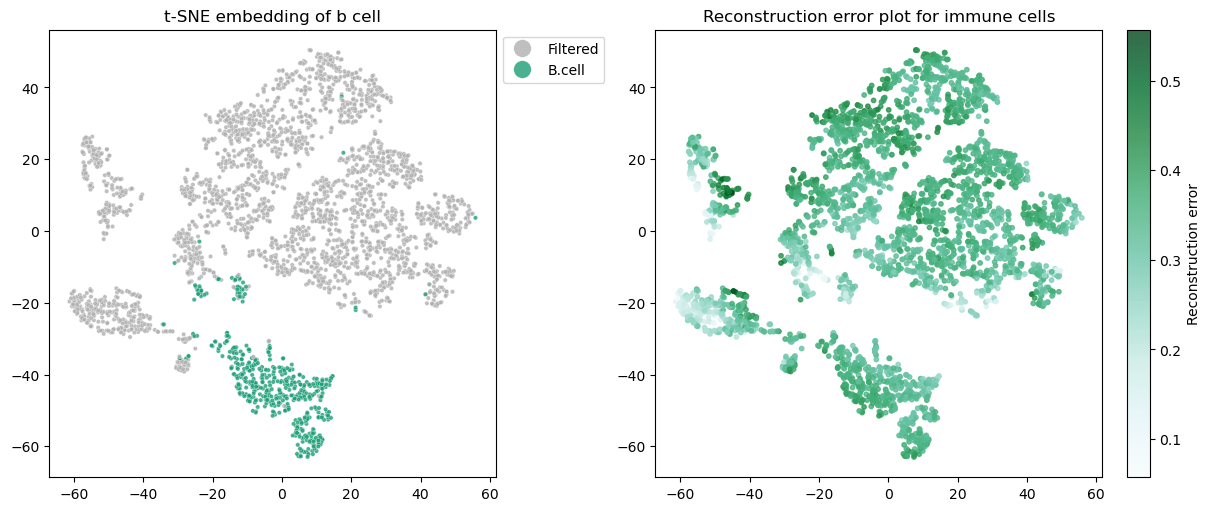

In [12]:
### immune-tSNE of b cell
b_indices=[i for i in range(tsne_embed.shape[0]) if cell_types_train[i]=='B.cell']

fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")


colors = ['Filtered' if x not in b_indices else cell_types_train[x]
          for x in range(tsne_embed.shape[0])]

# Build palette: gray for Background, other labels from Set2
unique_labels = sorted(set(colors))
palette = {}

# Gray for background
if 'Filtered' in unique_labels:
    palette['Filtered'] = '#b0b0b0'   # or 'lightgray'

# Colors for other labels
other_labels = [lab for lab in unique_labels if lab != 'Filtered']
base_palette = sns.color_palette('Dark2', n_colors=len(other_labels))
for lab, col in zip(other_labels, base_palette):
    palette[lab] = col

a = sns.scatterplot(
    x=tsne_embed[:, 0],
    y=tsne_embed[:, 1],
    alpha=0.8,
    ax=ax[0],
    hue=colors,
    palette=palette,
    s=10
)
sns.move_legend(a, "upper left", bbox_to_anchor=(1, 1), markerscale=4)

norm = mpl.colors.Normalize(vmin=recon_loss.min(), vmax=recon_loss.max())
sc = ax[1].scatter(
    tsne_embed[:, 0],
    tsne_embed[:, 1],
    c=recon_loss,
    cmap="BuGn",
    norm=norm,
    s=10,
    alpha=0.8
)
cbar = fig.colorbar(sc, ax=ax[1])
cbar.set_label("Reconstruction error")

#plt.tight_layout()
ax[0].set_title("t-SNE embedding of b cell")
ax[1].set_title("Reconstruction error plot for immune cells")

In [72]:
### immune-feature attribution for b cells
low_rec_avg=[]

ig=IntegratedGradients(model.encoder)

attr0=ig.attribute(torch.tensor(x_train[b_indices]).float(),
                          target=0,
                          n_steps=200)
attr1=ig.attribute(torch.tensor(x_train[b_indices]).float(),
                      target=1,
                      n_steps=200)

#normalization
row_min,_ = attr0.min(dim=1, keepdim=True)
row_max,_ = attr0.max(dim=1, keepdim=True)
denom=row_max-row_min
denom[denom==0]=1.0
attr0_norm=2*(attr0-row_min)/denom-1

row_min,_ = attr1.min(dim=1, keepdim=True)
row_max,_ = attr1.max(dim=1, keepdim=True)
denom=row_max-row_min
denom[denom==0]=1.0
attr1_norm=2*(attr1-row_min)/denom-1

low_rec_avg.append(torch.mean((torch.abs(attr0_norm)+torch.abs(attr1_norm))/2, dim=0).detach().cpu().numpy())

In [73]:
### immune-top features of b-differential type markers
top=10
top_feat_idx=np.argsort(np.abs(low_rec_avg[0]))[-top:]   #get the 10 genes with the highest feature attribution magnitudes idx
top_feat=[genes[j] for j in top_feat_idx]                #get the gene names

print("top feat", top_feat)

top_labels_diff=[1 if i in diff else 0 for i in top_feat] #prints if the genes are in differential markers list or not
top_labels_cell=[1 if i in cell else 0 for i in top_feat] #prints if the genes are in cell markers or not

print("top labels diff", top_labels_diff)
print("top labels cell", top_labels_cell)

#get_columns will print out the corresponding cell type to the passed top_labels_ which are the gene names
get_columns(top_feat, top_labels_diff, differential_markers)
get_columns(top_feat, top_labels_cell, cell_type_markers)

top feat ['HLA-A', 'TPT1', 'RPS11', 'RPS17L', 'MS4A1', 'HLA-DRB5', 'HLA-B', 'NAPSB', 'HSPA8', 'CD79B']
top labels diff [0, 1, 0, 0, 1, 1, 0, 1, 0, 1]
top labels cell [0, 0, 0, 0, 1, 0, 0, 0, 0, 1]
None T CD4 None None B CELL MACROPHAGE None B CELL None B CELL 
None None None None B CELL None None None None B CELL 
842


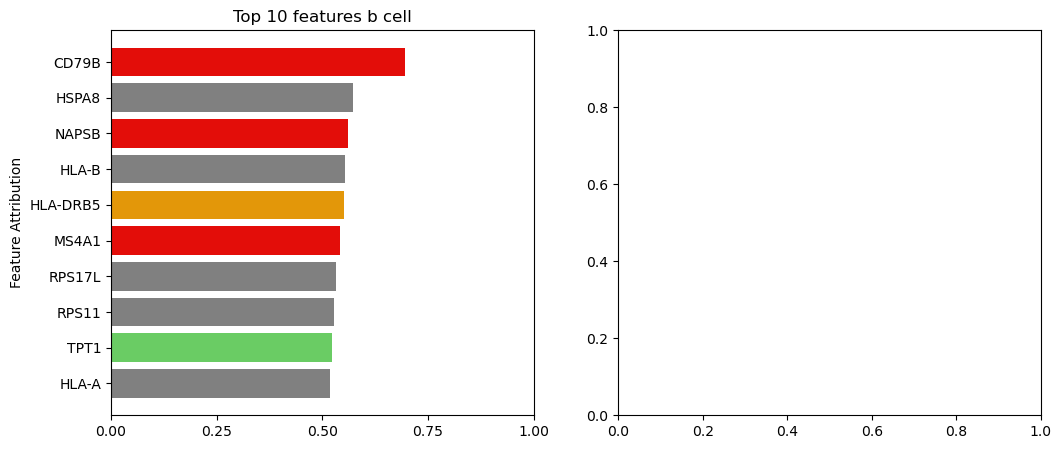

In [75]:
fig, ax=plt.subplots(1, 2, figsize=(12, 5))

ax[0].barh(top_feat, np.sort(np.abs(low_rec_avg[0]))[-10:], color=['gray','#6ACC64','gray','gray','#e30d09','#e39709','gray','#e30d09','gray','#e30d09'])
ax[0].set_title(f'Top 10 features b cell')
ax[0].set_ylabel('Feature Attribution')
ax[0].set_xticks([0,0.25,0.5,0.75,1])

Text(0.5, 1.0, 'Reconstruction error plot for immune cells')

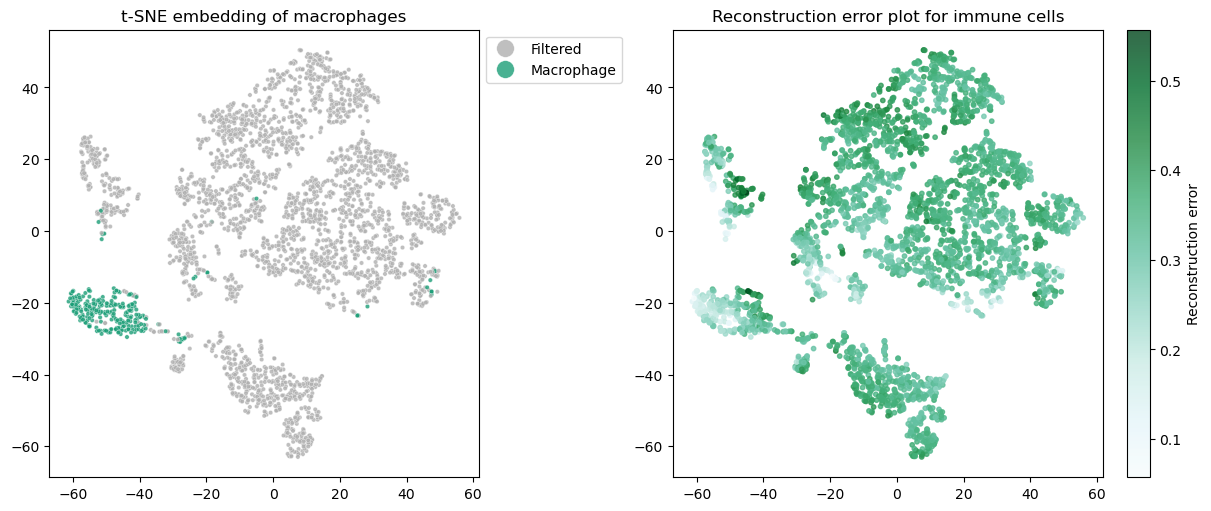

In [14]:
### immune-tSNE of macophages
macrophage_indices=[i for i in range(tsne_embed.shape[0]) if cell_types_train[i]=='Macrophage']

fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

colors = ['Filtered' if cell_types_train[x]!='Macrophage' else cell_types_train[x]
          for x in range(tsne_embed.shape[0])]

# Build palette: gray for Background, other labels from Set2
unique_labels = sorted(set(colors))
palette = {}

# Gray for background
if 'Filtered' in unique_labels:
    palette['Filtered'] = '#b0b0b0'   # or 'lightgray'

# Colors for other labels
other_labels = [lab for lab in unique_labels if lab != 'Filtered']
base_palette = sns.color_palette('Dark2', n_colors=len(other_labels))
for lab, col in zip(other_labels, base_palette):
    palette[lab] = col

a = sns.scatterplot(
    x=tsne_embed[:, 0],
    y=tsne_embed[:, 1],
    alpha=0.8,
    ax=ax[0],
    hue=colors,
    palette=palette,
    s=10
)
sns.move_legend(a, "upper left", bbox_to_anchor=(1, 1), markerscale=4)

norm = mpl.colors.Normalize(vmin=recon_loss.min(), vmax=recon_loss.max())
sc = ax[1].scatter(
    tsne_embed[:, 0],
    tsne_embed[:, 1],
    c=recon_loss,
    cmap="BuGn",
    norm=norm,
    s=10,
    alpha=0.8
)
cbar = fig.colorbar(sc, ax=ax[1])
cbar.set_label("Reconstruction error")

#plt.tight_layout()
ax[0].set_title("t-SNE embedding of macrophages")
ax[1].set_title("Reconstruction error plot for immune cells")

In [53]:
### immune-feature attribution for macrophage
low_rec_avg=[]

ig=IntegratedGradients(model.encoder)

attr0=ig.attribute(torch.tensor(x_train[macrophage_indices]).float(),
                          #baselines=torch.tensor(np.mean(train[labels_train==str(i)],axis=0,dtype=np.float32)).to('cuda'),
                          target=0,
                          n_steps=200)
attr1=ig.attribute(torch.tensor(x_train[macrophage_indices]).float(),
                      #baselines=torch.tensor(np.mean(train[labels_train==str(i)],axis=0,dtype=np.float32)).to('cuda'),
                      target=1,
                      n_steps=200)

#normalization
row_min,_ = attr0.min(dim=1, keepdim=True)
row_max,_ = attr0.max(dim=1, keepdim=True)
denom=row_max-row_min
denom[denom==0]=1.0
attr0_norm=2*(attr0-row_min)/denom-1

row_min,_ = attr1.min(dim=1, keepdim=True)
row_max,_ = attr1.max(dim=1, keepdim=True)
denom=row_max-row_min
denom[denom==0]=1.0
attr1_norm=2*(attr1-row_min)/denom-1

low_rec_avg.append(torch.mean((torch.abs(attr0_norm)+torch.abs(attr1_norm))/2, dim=0).detach().cpu().numpy())

In [33]:
### immune-top features of macrophages-differential type markers
top=10
top_feat_idx=np.argsort(np.abs(low_rec_avg[0]))[-top:]   #get the 10 genes with the highest feature attribution magnitudes idx
top_feat=[genes[j] for j in top_feat_idx]                #get the gene names

print("top feat", top_feat)

top_labels_diff=[1 if i in diff else 0 for i in top_feat] #prints if the genes are in differential markers list or not
top_labels_cell=[1 if i in cell else 0 for i in top_feat] #prints if the genes are in cell markers or not

print("top labels diff", top_labels_diff)
print("top labels cell", top_labels_cell)

#get_columns will print out the corresponding cell type to the passed top_labels_ which are the gene names
get_columns(top_feat, top_labels_diff, differential_markers)
get_columns(top_feat, top_labels_cell, cell_type_markers)

top feat ['RPL10A', 'RPL24', 'CYBB', 'AIF1', 'GPX1', 'CTSH', 'NACA', 'GRN', 'PTMA', 'RPL31']
top labels [0, 0, 1, 1, 1, 1, 0, 1, 0, 0]
None None MACROPHAGE MACROPHAGE MACROPHAGE MACROPHAGE None MACROPHAGE None None 
None None None None None None None None None None 
842


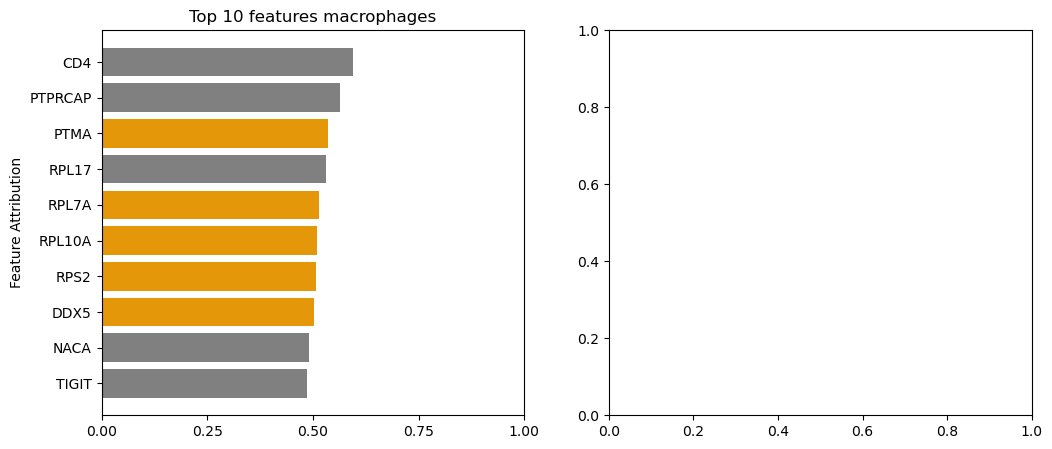

In [54]:
fig, ax=plt.subplots(1, 2, figsize=(12, 5))

ax[0].barh(top_feat, np.sort(np.abs(low_rec_avg[0]))[-10:], color=['gray']*2+['#e39709']*4+['gray','#e39709','gray','gray'])
ax[0].set_title(f'Top 10 features macrophages')
ax[0].set_ylabel('Feature Attribution')
ax[0].set_xticks([0,0.25,0.5,0.75,1])

Text(0.5, 1.0, 'Reconstruction error plot for immune cells')

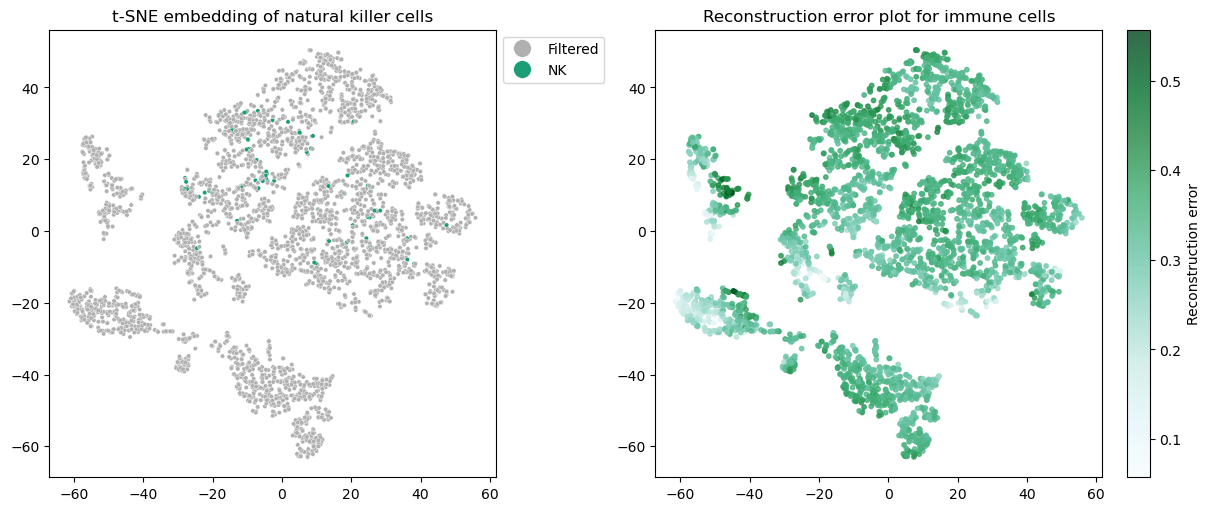

In [17]:
### immune-tSNE of NK
nk_indices=[i for i in range(tsne_embed.shape[0]) if cell_types_train[i]=='NK']

fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")


colors = ['Filtered' if x not in nk_indices else cell_types_train[x]
          for x in range(tsne_embed.shape[0])]

# Build palette: gray for Background, other labels from Set2
unique_labels = sorted(set(colors))
palette = {}

# Gray for background
if 'Filtered' in unique_labels:
    palette['Filtered'] = '#b0b0b0'   # or 'lightgray'

# Colors for other labels
other_labels = [lab for lab in unique_labels if lab != 'Filtered']
base_palette = sns.color_palette('Dark2', n_colors=len(other_labels))
for lab, col in zip(other_labels, base_palette):
    palette[lab] = col

a = sns.scatterplot(
    x=tsne_embed[:, 0],
    y=tsne_embed[:, 1],
    ax=ax[0],
    hue=colors,
    palette=palette,
    s=10
)
sns.move_legend(a, "upper left", bbox_to_anchor=(1, 1), markerscale=4)

norm = mpl.colors.Normalize(vmin=recon_loss.min(), vmax=recon_loss.max())
sc = ax[1].scatter(
    tsne_embed[:, 0],
    tsne_embed[:, 1],
    c=recon_loss,
    cmap="BuGn",
    norm=norm,
    s=10,
    alpha=0.8
)
cbar = fig.colorbar(sc, ax=ax[1])
cbar.set_label("Reconstruction error")

#plt.tight_layout()
ax[0].set_title("t-SNE embedding of natural killer cells")
ax[1].set_title("Reconstruction error plot for immune cells")

In [41]:
### immune-feature attribution for NK
low_rec_avg=[]

ig=IntegratedGradients(model.encoder)

attr0=ig.attribute(torch.tensor(x_train[nk_indices]).float(),
                          #baselines=torch.tensor(np.mean(train[labels_train==str(i)],axis=0,dtype=np.float32)).to('cuda'),
                          target=0,
                          n_steps=200)
attr1=ig.attribute(torch.tensor(x_train[nk_indices]).float(),
                      #baselines=torch.tensor(np.mean(train[labels_train==str(i)],axis=0,dtype=np.float32)).to('cuda'),
                      target=1,
                      n_steps=200)

#normalization
row_min,_ = attr0.min(dim=1, keepdim=True)
row_max,_ = attr0.max(dim=1, keepdim=True)
denom=row_max-row_min
denom[denom==0]=1.0
attr0_norm=2*(attr0-row_min)/denom-1

row_min,_ = attr1.min(dim=1, keepdim=True)
row_max,_ = attr1.max(dim=1, keepdim=True)
denom=row_max-row_min
denom[denom==0]=1.0
attr1_norm=2*(attr1-row_min)/denom-1

low_rec_avg.append(torch.mean((torch.abs(attr0_norm)+torch.abs(attr1_norm))/2, dim=0).detach().cpu().numpy())

In [42]:
### immune-top features of nk-differential type markers
top=10
top_feat_idx=np.argsort(np.abs(low_rec_avg[0]))[-top:]   #get the 10 genes with the highest feature attribution magnitudes idx
top_feat=[genes[j] for j in top_feat_idx]                #get the gene names

print("top feat", top_feat)

top_labels_diff=[1 if i in diff else 0 for i in top_feat] #prints if the genes are in differential markers list or not
top_labels_cell=[1 if i in cell else 0 for i in top_feat] #prints if the genes are in cell markers or not

print("top labels diff", top_labels_diff)
print("top labels cell", top_labels_cell)

#get_columns will print out the corresponding cell type to the passed top_labels_ which are the gene names
get_columns(top_feat, top_labels_diff, differential_markers)
get_columns(top_feat, top_labels_cell, cell_type_markers)

top feat ['PTMA', 'RPL37A', 'MTRNR2L8', 'GNLY', 'CALM1', 'RPL17', 'KLRB1', 'NKG7', 'KLRK1', 'CCL4']
top labels [0, 0, 1, 1, 1, 1, 0, 1, 0, 0]
None None None NK NK None NK NK None T CD8 CYTOTOXIC 
None None None None None None NK CELL CYTOTOXIC CD8 T CELL NK CELL CYTOTOXIC CD8 T CELL 
842


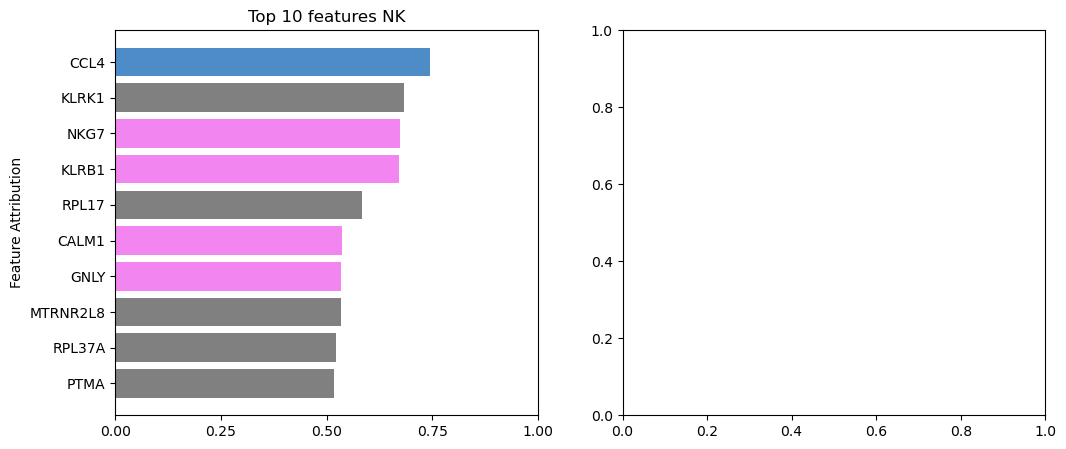

In [44]:
fig, ax=plt.subplots(1, 2, figsize=(12, 5))

ax[0].barh(top_feat, np.sort(np.abs(low_rec_avg[0]))[-10:], color=['gray']*3+['#f285f0']*2+['gray','#f285f0','#f285f0','gray','#4e8cc7'])
ax[0].set_title(f'Top 10 features NK')
ax[0].set_ylabel('Feature Attribution')
ax[0].set_xticks([0,0.25,0.5,0.75,1])